# Tugas 1 - Klasifikasi Wine Quality dengan KNN
**Nama:** Catherine Aprilia Harlina  
**NRP:** [5054251012]

---

In [27]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [28]:
df = pd.read_csv('WineQT.csv').drop(columns=['Id'], errors='ignore')
display(df.head()); df.info(); display(df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


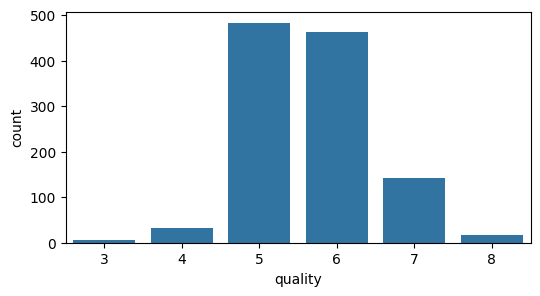

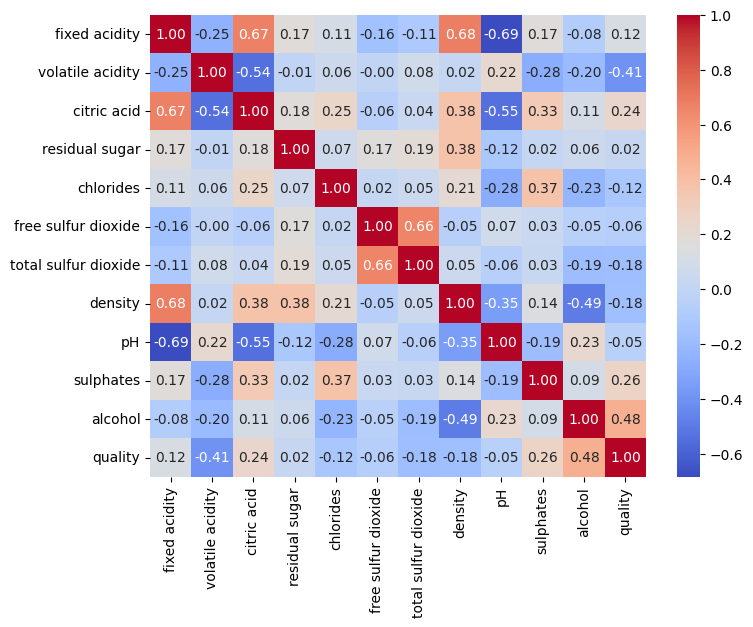

In [29]:
plt.figure(figsize=(6,3)); sns.countplot(x='quality', data=df); plt.show()
plt.figure(figsize=(8,6)); sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm'); plt.show()

null: 0 | dup: 125


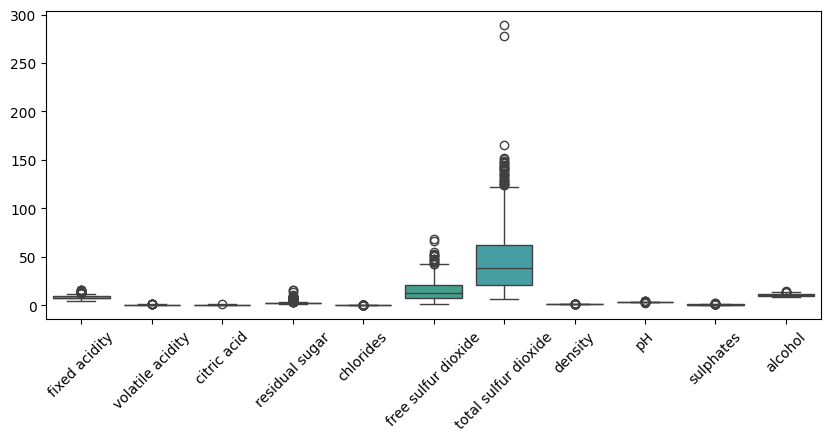

In [30]:
print(f"null: {df.isnull().sum().sum()} | dup: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)

plt.figure(figsize=(10,4)); sns.boxplot(data=df.drop(columns=['quality'])); plt.xticks(rotation=45); plt.show()

In [31]:
X, y = df.drop(columns=['quality']), df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)
print(f"train: {X_train.shape} | test: {X_test.shape}")

train: (814, 11) | test: (204, 11)


In [32]:
res = []
for m in ['euclidean', 'manhattan']:
    for k in [3, 5, 7]:
        knn = KNeighborsClassifier(n_neighbors=k, metric=m).fit(X_train, y_train)
        pred = knn.predict(X_test)
        res.append({
            'metric': m, 'k': k,
            'acc': round(accuracy_score(y_test, pred), 4),
            'prec': round(precision_score(y_test, pred, average='weighted', zero_division=0), 4),
            'rec': round(recall_score(y_test, pred, average='weighted', zero_division=0), 4),
            'f1': round(f1_score(y_test, pred, average='weighted', zero_division=0), 4)
        })

df_res = pd.DataFrame(res); display(df_res)

,metric,k,acc,prec,rec,f1
0,euclidean,3,0.5098,0.5169,0.5098,0.5122
1,euclidean,5,0.5588,0.5416,0.5588,0.5498
2,euclidean,7,0.5686,0.5516,0.5686,0.5593
3,manhattan,3,0.4706,0.4728,0.4706,0.4710
4,manhattan,5,0.4804,0.4630,0.4804,0.4704
5,manhattan,7,0.5539,0.5293,0.5539,0.5398


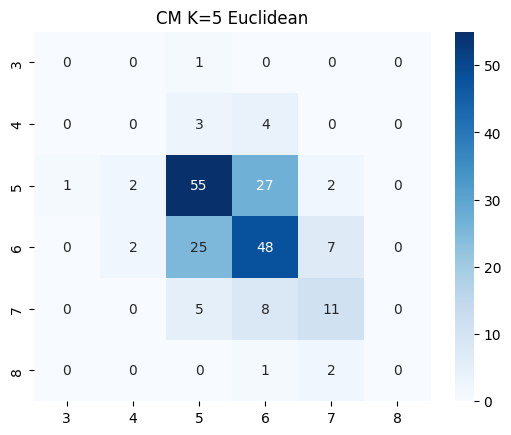

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.62      0.63      0.62        87
           6       0.55      0.59      0.56        82
           7       0.50      0.46      0.48        24
           8       0.00      0.00      0.00         3

    accuracy                           0.56       204
   macro avg       0.28      0.28      0.28       204
weighted avg       0.54      0.56      0.55       204



In [33]:
model = KNeighborsClassifier(n_neighbors=5, metric='euclidean').fit(X_train, y_train)
pred = model.predict(X_test)

sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('CM K=5 Euclidean'); plt.show()
print(classification_report(y_test, pred, zero_division=0))

## 5. Analisis
* **Nilai K:** K=3 rawan kena noise/outlier. K=5 sama K=7 jauh lebih stabil hasilnya karena batas keputusannya lebih halus.
* **Jarak (Metric):** Euclidean sama Manhattan hasilnya 11-12 mirip banget, soalnya data udah di-scale dulu pake StandardScaler.
* **Scaling:** Wajib banget pake StandardScaler biar fitur yang rentangnya gede kaya `total sulfur dioxide` gak mendominasi fitur kecil kaya `citric acid`.

## 6. Kesimpulan & Saran
* **Kesimpulan:** KNN lancar dipake buat prediksi quality wine. Hasil terbaik dapet di K=5 / K=7 pake Euclidean + StandardScaler.
* **Saran:** Label quality-nya gak seimbang (kebanyakan di nilai 5 & 6), next eksperimen bisa coba pake SMOTE atau ganti model ke Random Forest/XGBoost.